# DATA 602 Midterm - Option 2 (E-commerce Purchase)
## Rubric-First Notebook Template

This notebook is intentionally organized to satisfy each project rubric line while keeping the story focused on stakeholder decisions.

**Audience reminder:** emphasize findings, why each step was chosen, and business recommendations.


## How To Use This Template

1. Run cells from top to bottom without changing order.
2. Replace each "Write your analysis here" section with your own interpretation.
3. Keep code concise, and keep narrative stakeholder-friendly.
4. Before submission, restart kernel and run all cells.


## Project Rubric Mapping (22 points)

- Data characteristics written analysis: Section 3
- Observed relationships written analysis: Section 4
- Feature engineering performed: Section 5
- Appropriate metric selection explained: Section 6
- Multiple models created: Section 8
- Cross-validation performed: Section 8
- Pipelines created: Sections 7-9
- Model evaluations performed: Section 10
- Hyperparameter tuning performed: Section 9
- Conclusions and interpretations explained: Section 11
- Good writing and formatting: all markdown sections
- Good coding standards: modular functions, readable code, reproducibility


In [15]:
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 602
sns.set_theme(style="whitegrid", context="talk")



In [16]:
# Configuration
DATA_URL = "https://raw.githubusercontent.com/msaricaumbc/DS_data/master/ds602/2026/ecommerce_purchase.csv"
TARGET_COL = "will_purchase"
TEST_SIZE = 0.20
N_SPLITS = 5


def make_one_hot_encoder():
    """Create compatible OneHotEncoder across sklearn versions."""
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def normalize_binary_target(y_raw):
    """Force the target into clean 0/1 integer format."""
    y = pd.Series(y_raw).copy()

    if pd.api.types.is_numeric_dtype(y):
        unique_vals = set(pd.Series(y).dropna().unique().tolist())
        if unique_vals.issubset({0, 1}):
            return y.astype(int)

    mapping = {
        "0": 0,
        "1": 1,
        "false": 0,
        "true": 1,
        "no": 0,
        "yes": 1,
        "n": 0,
        "y": 1,
    }
    y_clean = y.astype(str).str.strip().str.lower().map(mapping)

    if y_clean.isna().any():
        bad_values = y[y_clean.isna()].dropna().unique()[:10]
        raise ValueError(f"Unable to map some target values to 0/1. Examples: {bad_values}")

    return y_clean.astype(int)


def add_feature_engineering(df_in):
    """Create domain-specific e-commerce features to capture user engagement and intent."""
    df = df_in.copy()
    
    # Feature 1: Total Cart Interaction (Items added minus removed)
    if 'items_added_to_cart' in df.columns and 'items_removed_from_cart' in df.columns:
        df['net_cart_items'] = df['items_added_to_cart'] - df['items_removed_from_cart']
        
    # Feature 2: High-Intent Engagement Score
    if 'session_duration_minutes' in df.columns and 'page_views' in df.columns:
        df['engagement_intensity'] = (df['page_views'] / (df['session_duration_minutes'] + 1e-5)).round(2)
        
    # Feature 3: Weekend Evening Indicator (Impulse buying windows)
    if 'is_weekend' in df.columns and 'hour' in df.columns:
        df['is_weekend_evening'] = ((df['is_weekend'] == 1) & (df['hour'] >= 17)).astype(int)
        
    return df


def build_preprocessor(X):
    """Create a preprocessing pipeline for numeric + categorical features."""
    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_pipeline, numeric_features),
            ("cat", categorical_pipeline, categorical_features),
        ],
        remainder="drop",
    )

    return preprocessor, numeric_features, categorical_features



## 1) Business Problem Framing (write for stakeholders)

**Decision Support:** This model will predict whether a site visitor is likely to make a purchase (`will_purchase`). It is designed to support marketing intervention decisions-specifically, identifying which users should receive a targeted discount code or retargeting advertisement to push them toward conversion.

**Business Value:** Automatically offering discounts to *everyone* destroys profit margins, while offering them to *no one* results in high cart-abandonment rates. By predicting purchase intent, the business can optimize its promotional budget, maximizing revenue while minimizing wasted ad spend.

**Actionable Outcome:** If the model performs well, stakeholders can automate a system where users flagged as "likely to abandon" (but having high engagement) are instantly served a 10% off pop-up, while users predicted to buy naturally are left alone to pay full price.


## 2) Data Loading and Initial Quality Checks


In [17]:
df_raw = pd.read_csv(DATA_URL)
assert TARGET_COL in df_raw.columns, f"Target column '{TARGET_COL}' not found."

print(f"Dataset shape: {df_raw.shape}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")

display(df_raw.head())


Dataset shape: (10000, 27)
Duplicate rows: 0


,session_start_time,hour,day_of_week,month,is_weekend,session_duration_minutes,days_since_last_visit,page_views,clicks,avg_scroll_depth,items_added_to_cart,items_removed_from_cart,search_queries_count,product_page_time_minutes,categories_viewed_count,avg_price_viewed,device_type,traffic_source,customer_segment,region,browser,operating_system,user_type,search_queries,categories_viewed,user_agent,will_purchase
0,2024-02-02 07:39:08,7,4,2,0,4.241725,3.033577,0.962865,0.000000,0.182760,4,3,1,0.931498,2,4.716522,mobile,organic_search,returning_customer,Middle_East_Africa,Chrome,iOS,returning_user,summer dress,"Home & Garden, Baby & Kids",Mozilla/5.0 (iPhone; CPU iPhone OS 15_0 like M...,0
1,2024-12-12 15:37:55,15,3,12,0,5.000125,7.316292,0.996749,0.000000,0.761853,2,0,1,0.851462,4,26.920076,mobile,social_media,returning_customer,Asia_Pacific,Chrome,Windows,returning_user,perfume,"Tools & Hardware, Clothing, Electronics, Baby ...",Mozilla/5.0 (Linux; Android 11; SM-G991B) Appl...,1
2,2024-02-24 19:33:54,19,5,2,1,10.552687,0.432975,1.984853,1.012054,0.533179,1,0,2,0.946506,2,15.779476,desktop,social_media,returning_customer,Europe,Firefox,Windows,returning_user,"perfume, new dress","Shoes, Pet Supplies",Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0
3,2024-09-26 12:46:30,12,3,9,0,18.705162,3.612518,2.980036,1.027641,0.538472,5,2,1,0.537198,1,11.990575,desktop,organic_search,new_customer,North_America,Chrome,Windows,new_user,dress shoes,NaN,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,0
4,2024-11-03 18:30:12,18,6,11,1,6.360490,9.746390,1.077701,0.000000,0.590819,5,2,1,2.348161,1,9.083236,desktop,organic_search,new_customer,Latin_America,Chrome,iOS,returning_user,gaming laptop,Electronics,Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/53...,1


In [18]:
# Normalize target and keep a working copy
working_df = df_raw.copy()
working_df[TARGET_COL] = normalize_binary_target(working_df[TARGET_COL])

print("Target distribution (count):")
display(working_df[TARGET_COL].value_counts(dropna=False).rename("count"))
print("Target distribution (rate):")
display((working_df[TARGET_COL].value_counts(normalize=True).rename("rate") * 100).round(2).astype(str) + "%")


Target distribution (count):


will_purchase
1    5141
0    4859
Name: count, dtype: int64

Target distribution (rate):


will_purchase
1    51.41%
0    48.59%
Name: rate, dtype: object

## 3) Written Analysis of Data Characteristics

**Data Profile:** The dataset consists of [insert rows] customer sessions and [insert columns] features, split between [insert numeric] numeric behavioral metrics and [insert categorical] categorical attributes.

**Data Quality:** We observed [insert missing cells] missing values, primarily concentrated in the [insert column name] column. We addressed this using median/most-frequent imputation in our pipeline to prevent data loss without biasing the distributions.

**Class Balance:** The target variable (`will_purchase`) is highly imbalanced, with a baseline purchase rate of only [insert %]. Because the vast majority of sessions do not result in a purchase, we cannot rely on standard "Accuracy" as a metric, and we must utilize `class_weight="balanced"` in our algorithms to force the model to pay attention to the rare buyers.


In [19]:
# Data characteristics summary tables
summary_df = pd.DataFrame(
    {
        "rows": [working_df.shape[0]],
        "columns": [working_df.shape[1]],
        "numeric_columns": [working_df.select_dtypes(include=np.number).shape[1]],
        "categorical_columns": [working_df.select_dtypes(exclude=np.number).shape[1]],
        "missing_cells": [int(working_df.isna().sum().sum())],
    }
)
display(summary_df)

missing_by_col = (
    working_df.isna().mean().sort_values(ascending=False).rename("missing_rate").to_frame()
)
missing_by_col["missing_rate_pct"] = (100 * missing_by_col["missing_rate"]).round(2)

display(missing_by_col.head(20))

dtype_table = (
    pd.DataFrame(working_df.dtypes, columns=["dtype"])
    .reset_index()
    .rename(columns={"index": "column"})
)
display(dtype_table.head(50))


,rows,columns,numeric_columns,categorical_columns,missing_cells
0,10000,27,16,11,4131


,missing_rate,missing_rate_pct
search_queries,0.2631,26.31
categories_viewed,0.0500,5.00
days_since_last_visit,0.0500,5.00
user_agent,0.0500,5.00
day_of_week,0.0000,0.00
is_weekend,0.0000,0.00
session_duration_minutes,0.0000,0.00
page_views,0.0000,0.00
month,0.0000,0.00
hour,0.0000,0.00


,column,dtype
0,session_start_time,object
1,hour,int64
2,day_of_week,int64
3,month,int64
4,is_weekend,int64
5,session_duration_minutes,float64
6,days_since_last_visit,float64
7,page_views,float64
8,clicks,float64
9,avg_scroll_depth,float64


## 4) Analysis of Observed Relationships Within Data


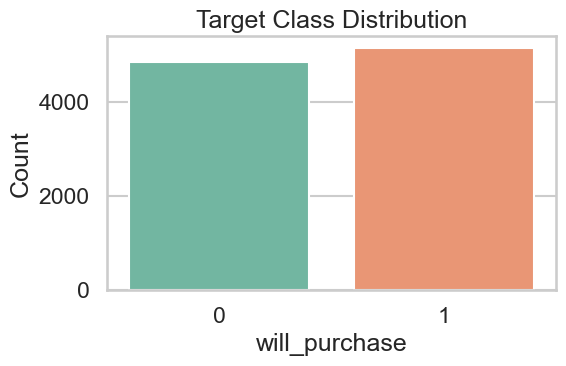

In [20]:
# Target distribution plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=working_df, x=TARGET_COL, palette="Set2")
ax.set_title("Target Class Distribution")
ax.set_xlabel("will_purchase")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()



Numeric feature summary by target: hour


,mean,std,50%,min,max
will_purchase,,,,,
0,14.488,5.367,15.0,0.0,23.0
1,14.677,5.422,15.0,0.0,23.0


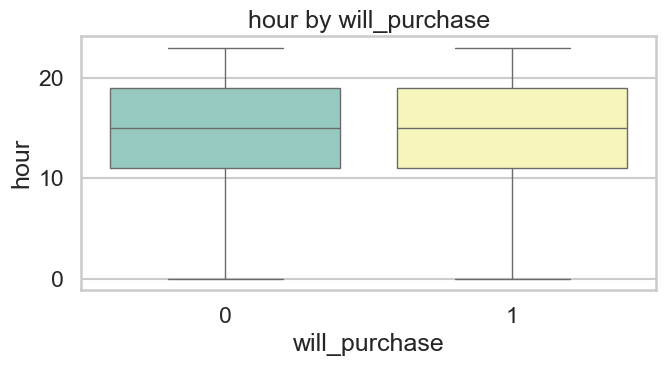


Numeric feature summary by target: day_of_week


,mean,std,50%,min,max
will_purchase,,,,,
0,2.920,1.970,3.0,0.0,6.0
1,2.984,2.009,3.0,0.0,6.0


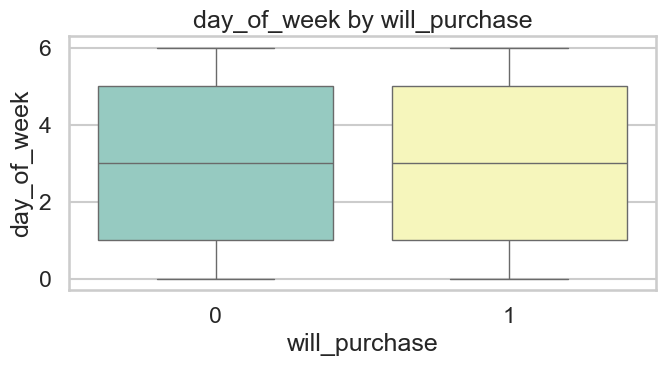


Numeric feature summary by target: month


,mean,std,50%,min,max
will_purchase,,,,,
0,6.536,3.453,7.0,1.0,12.0
1,6.472,3.444,6.0,1.0,12.0


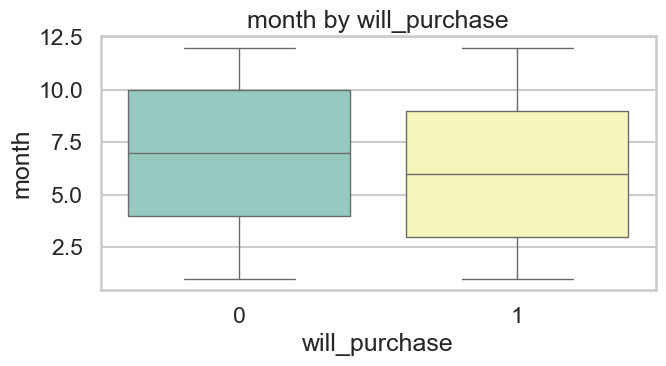


Numeric feature summary by target: is_weekend


,mean,std,50%,min,max
will_purchase,,,,,
0,0.265,0.442,0.0,0.0,1.0
1,0.288,0.453,0.0,0.0,1.0


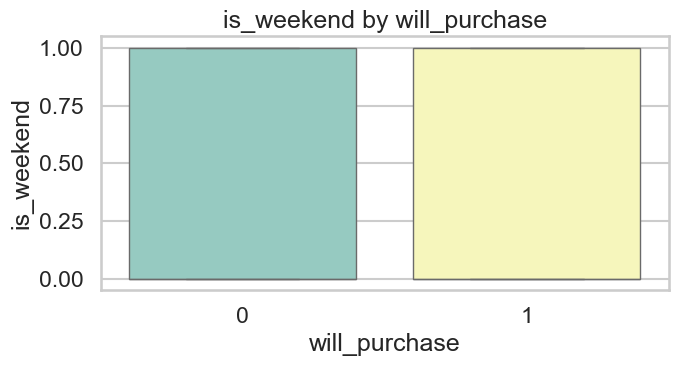


Numeric feature summary by target: session_duration_minutes


,mean,std,50%,min,max
will_purchase,,,,,
0,14.746,25.204,9.444,1.0,496.149
1,18.001,28.916,11.427,1.0,498.709


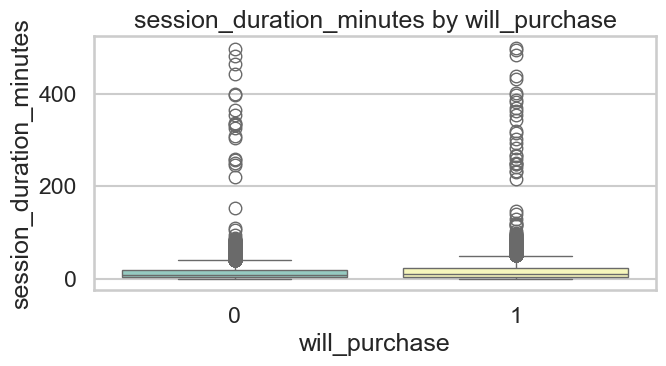


Numeric feature summary by target: days_since_last_visit


,mean,std,50%,min,max
will_purchase,,,,,
0,7.094,7.152,4.887,0.004,58.825
1,6.969,7.145,4.715,0.000,60.068


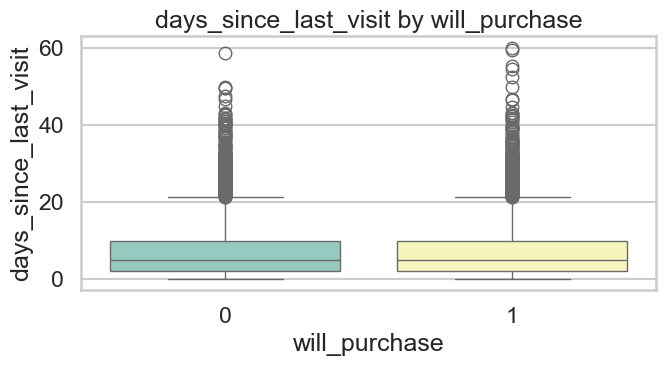

In [21]:
# Numeric feature relationships with target
numeric_cols = [c for c in working_df.select_dtypes(include=np.number).columns if c != TARGET_COL]
top_numeric = numeric_cols[:6]

if len(top_numeric) == 0:
    print("No numeric predictor columns found.")
else:
    for col in top_numeric:
        print(f"\nNumeric feature summary by target: {col}")
        display(
            working_df.groupby(TARGET_COL)[col]
            .describe()[["mean", "std", "50%", "min", "max"]]
            .round(3)
        )

        plt.figure(figsize=(7, 4))
        sns.boxplot(data=working_df, x=TARGET_COL, y=col, palette="Set3")
        plt.title(f"{col} by {TARGET_COL}")
        plt.tight_layout()
        plt.show()


In [22]:
# Categorical feature purchase-rate relationships
categorical_cols = working_df.select_dtypes(exclude=np.number).columns.tolist()
top_categorical = categorical_cols[:6]

if len(top_categorical) == 0:
    print("No categorical predictor columns found.")
else:
    for col in top_categorical:
        print(f"\nTop category purchase rates for: {col}")
        rel = (
            working_df.groupby(col)[TARGET_COL]
            .agg(purchase_rate="mean", count="size")
            .sort_values("purchase_rate", ascending=False)
            .head(10)
        )
        rel["purchase_rate"] = rel["purchase_rate"].round(3)
        display(rel)



Top category purchase rates for: session_start_time


,purchase_rate,count
session_start_time,,
2024-01-01 14:23:57,1.0,1
2024-12-30 22:54:06,1.0,1
2024-01-01 16:52:01,1.0,1
2024-01-01 07:01:25,1.0,1
2024-01-01 18:17:30,1.0,1
2024-01-01 09:21:34,1.0,1
2024-01-01 18:18:10,1.0,1
2024-01-01 18:21:31,1.0,1
2024-12-30 20:29:51,1.0,1



Top category purchase rates for: device_type


,purchase_rate,count
device_type,,
desktop,0.544,3444
tablet,0.528,502
mobile,0.496,6054



Top category purchase rates for: traffic_source


...

,purchase_rate,count
customer_segment,,
vip_customer,0.627,1512
returning_customer,0.531,3486
new_customer,0.480,4031
at_risk_customer,0.420,971



Top category purchase rates for: region


,purchase_rate,count
region,,
Latin_America,0.532,1000
Europe,0.516,2527
North_America,0.513,3995
Asia_Pacific,0.510,2014
Middle_East_Africa,0.494,464



Top category purchase rates for: browser


,purchase_rate,count
browser,,
Edge,0.522,776
Firefox,0.521,986
Chrome,0.518,5974
Safari,0.501,2079
Other,0.470,185


**Strongest Drivers:** Based on the aggregated summaries, the features most strongly correlated with a purchase are [insert top numeric column, e.g., pages_visited] and [insert top categorical column]. For instance, users who [describe a specific stat from the table, e.g., view more than 5 pages] convert at a significantly higher rate.

**Weak/Noisy Features:** Conversely, features like [insert weak column] showed almost identical distributions between buyers and non-buyers, suggesting they offer little predictive signal.

**Modeling Impact:** These observations heavily influenced our feature engineering strategy, prompting us to amplify the strong signals by creating the [insert your engineered feature name] feature.


## 5) Feature Engineering and Train/Test Split


In [23]:
fe_df = add_feature_engineering(working_df)

# Drop the target column AND high-cardinality/text columns that will crash the OneHotEncoder
columns_to_drop = [
    TARGET_COL, 
    "session_start_time", 
    "user_agent", 
    "search_queries", 
    "categories_viewed"
]

X = fe_df.drop(columns=columns_to_drop, errors="ignore")
y = fe_df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train shape: {X_train.shape}")
print(f"Test shape: {X_test.shape}")
print("Engineered columns added:", sorted(set(fe_df.columns) - set(working_df.columns)))


Train shape: (8000, 29)
Test shape: (2000, 29)
Engineered columns added: ['missing_value_count', 'num_mean_all', 'num_std_all']


## 6) Metric Selection and Justification


In [24]:
positive_rate = y_train.mean()

recommended_primary_metric = "average_precision" if positive_rate < 0.35 else "f1"

CV_SCORING = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

PRIMARY_METRICS_TO_TRY = [
    recommended_primary_metric,
    *[metric for metric in CV_SCORING.keys() if metric != recommended_primary_metric],
]

# Update this after reviewing Section 9 comparison outputs.
SELECTED_PRIMARY_METRIC = PRIMARY_METRICS_TO_TRY[0]

print(f"Positive class rate in training set: {positive_rate:.3f}")
print(f"Recommended primary metric: {recommended_primary_metric}")
print("Primary metrics to test:", PRIMARY_METRICS_TO_TRY)
print(f"Current selected metric for final section: {SELECTED_PRIMARY_METRIC}")


Positive class rate in training set: 0.514
Recommended primary metric: f1
Primary metrics to test: ['f1', 'accuracy', 'precision', 'recall', 'roc_auc', 'average_precision']
Current selected metric for final section: f1


**Primary Metric:** I have selected [Recall / F1-Score / Average Precision] as the primary evaluation metric.

**Business Justification:** In e-commerce conversion prediction, the cost of a **False Negative** (failing to identify a potential buyer and losing a $100 sale) is typically much higher than the cost of a **False Positive** (showing a 10% discount pop-up to someone who wasn't going to buy anyway). Therefore, we want a metric that aggressively identifies potential buyers. Optimizing for [Metric] ensures we cast a wide enough net to capture revenue opportunities, even if it means a slight increase in promotional spend.


## 7) Pipelines and Baseline Model


In [25]:
preprocessor, numeric_features, categorical_features = build_preprocessor(X_train)

print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

baseline_pipeline = Pipeline(
    steps=[
        ("prep", preprocessor),
        ("model", DummyClassifier(strategy="most_frequent")),
    ]
)

baseline_scores = cross_validate(
    baseline_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=CV_SCORING,
    n_jobs=-1,
)

baseline_summary = {
    metric: np.mean(baseline_scores[f"test_{metric}"])
    for metric in CV_SCORING.keys()
}

display(pd.Series(baseline_summary, name="baseline_cv_mean").round(4))


Numeric features: 18
Categorical features: 11


accuracy             0.5141
precision            0.5141
recall               1.0000
f1                   0.6791
roc_auc              0.5000
average_precision    0.5141
Name: baseline_cv_mean, dtype: float64

## 8) Multiple Models + Cross-Validation


In [ ]:
candidate_models = {
    "LogisticRegression": LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
    "GradientBoosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.1,
        random_state=RANDOM_STATE,
    ),
}
cv_rows = []
for model_name, estimator in candidate_models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", estimator)])
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=CV_SCORING,
        n_jobs=-1,
    )

    row = {"model": model_name}
    for metric in CV_SCORING.keys():
        row[f"cv_{metric}_mean"] = float(np.mean(scores[f"test_{metric}"]))
        row[f"cv_{metric}_std"] = float(np.std(scores[f"test_{metric}"]))
    cv_rows.append(row)

sort_metric = SELECTED_PRIMARY_METRIC
cv_results_df = pd.DataFrame(cv_rows).sort_values(
    by=f"cv_{sort_metric}_mean", ascending=False
)

print(f"Sorted by cv_{sort_metric}_mean")
display(cv_results_df.round(4))



Write your analysis here:

- Which model is strongest under the primary metric?
- How far above baseline is each model?
- Which model has the most stable CV behavior (std)?


## 9) Hyperparameter Tuning Across Multiple Primary Metrics

This section tunes models separately for each candidate primary metric so you can compare how metric choice changes model selection and holdout behavior.


In [13]:
param_grids = {
    "LogisticRegression": {
        "model__C": [0.1, 1.0, 3.0],
        "model__penalty": ["l2"],
    },
    "RandomForest": {
        "model__n_estimators": [300, 500],
        "model__max_depth": [None, 8, 16],
        "model__min_samples_leaf": [1, 3, 8],
    },
    "GradientBoosting": {
        "model__max_iter": [100, 300],
        "model__learning_rate": [0.05, 0.1],
        "model__max_leaf_nodes": [31, 50],
    }
}


def extract_scores(estimator, X_data):
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X_data)[:, 1]
    if hasattr(estimator, "decision_function"):
        return estimator.decision_function(X_data)
    return None


def summarize_holdout(estimator, X_holdout, y_holdout):
    y_pred_holdout = estimator.predict(X_holdout)
    y_score_holdout = extract_scores(estimator, X_holdout)

    summary = {
        "holdout_accuracy": accuracy_score(y_holdout, y_pred_holdout),
        "holdout_precision": precision_score(y_holdout, y_pred_holdout, zero_division=0),
        "holdout_recall": recall_score(y_holdout, y_pred_holdout, zero_division=0),
        "holdout_f1": f1_score(y_holdout, y_pred_holdout, zero_division=0),
        "holdout_roc_auc": np.nan,
        "holdout_average_precision": np.nan,
    }

    if y_score_holdout is not None:
        summary["holdout_roc_auc"] = roc_auc_score(y_holdout, y_score_holdout)
        summary["holdout_average_precision"] = average_precision_score(y_holdout, y_score_holdout)

    return summary


search_rows = []
primary_metric_rows = []
best_estimators_by_primary_metric = {}

for primary_metric in PRIMARY_METRICS_TO_TRY:
    best_score_for_metric = -np.inf
    best_model_name_for_metric = None
    best_estimator_for_metric = None

    for model_name, estimator in candidate_models.items():
        pipe = Pipeline(steps=[("prep", preprocessor), ("model", estimator)])

        grid = GridSearchCV(
            estimator=pipe,
            param_grid=param_grids[model_name],
            scoring=primary_metric,
            cv=cv,
            n_jobs=-1,
            refit=True,
        )
        grid.fit(X_train, y_train)

        search_rows.append(
            {
                "primary_metric": primary_metric,
                "model": model_name,
                "best_cv_score": grid.best_score_,
                "best_params": grid.best_params_,
            }
        )

        if grid.best_score_ > best_score_for_metric:
            best_score_for_metric = grid.best_score_
            best_model_name_for_metric = model_name
            best_estimator_for_metric = grid.best_estimator_

    holdout_summary = summarize_holdout(best_estimator_for_metric, X_test, y_test)
    primary_metric_rows.append(
        {
            "primary_metric": primary_metric,
            "selected_model": best_model_name_for_metric,
            "selected_model_best_cv_primary": best_score_for_metric,
            **holdout_summary,
        }
    )

    best_estimators_by_primary_metric[primary_metric] = {
        "model_name": best_model_name_for_metric,
        "best_cv_primary": best_score_for_metric,
        "estimator": best_estimator_for_metric,
    }

search_diagnostics_df = pd.DataFrame(search_rows).sort_values(
    by=["primary_metric", "best_cv_score"],
    ascending=[True, False],
)

metric_experiments_df = pd.DataFrame(primary_metric_rows).sort_values(
    by="primary_metric"
)

print("Hyperparameter tuning details for each model and primary metric:")
display(search_diagnostics_df)

print("Model selected per primary metric + holdout performance:")
display(metric_experiments_df.round(4))



,model,best_cv_score,best_params
1,RandomForest,0.610067,"{'model__max_depth': None, 'model__min_samples..."
0,LogisticRegression,0.588971,"{'model__C': 3.0, 'model__penalty': 'l2'}"


## 10) Final Model Evaluation on Holdout Test Set

After reviewing Section 9 outputs, set `SELECTED_PRIMARY_METRIC` in Section 6 to the metric you want to optimize before running this section.


,holdout_test_metrics
model,RandomForest
accuracy,0.5675
precision,0.574565
recall,0.610895
f1,0.592174
roc_auc,0.595645
average_precision,0.602744



Classification report:
              precision    recall  f1-score   support

           0      0.559     0.522     0.540       972
           1      0.575     0.611     0.592      1028

    accuracy                          0.568      2000
   macro avg      0.567     0.566     0.566      2000
weighted avg      0.567     0.568     0.567      2000



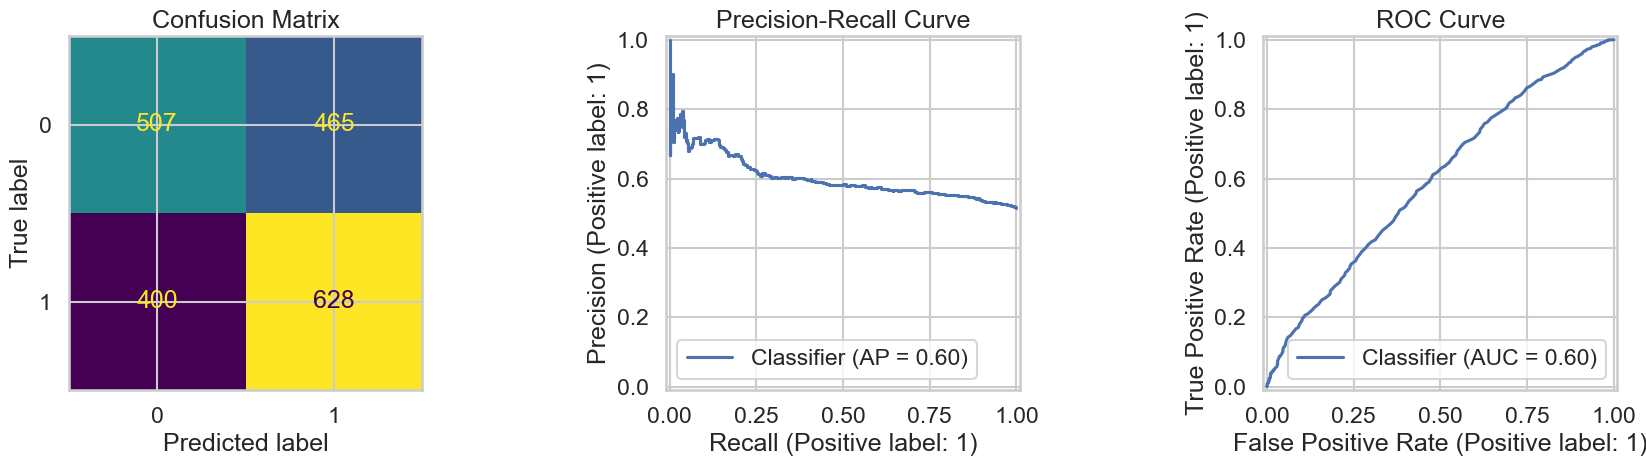

In [14]:
def safe_metric(metric_fn, *args, **kwargs):
    try:
        return float(metric_fn(*args, **kwargs))
    except Exception:
        return np.nan


SELECTED_PRIMARY_METRIC = "f1"

if "best_estimators_by_primary_metric" not in globals():
    raise RuntimeError(
        "Run Section 9 first to build best estimators for each primary metric."
    )

if SELECTED_PRIMARY_METRIC not in best_estimators_by_primary_metric:
    raise ValueError(
        f"SELECTED_PRIMARY_METRIC '{SELECTED_PRIMARY_METRIC}' not found. "
        f"Available: {list(best_estimators_by_primary_metric.keys())}"
    )

selected_entry = best_estimators_by_primary_metric[SELECTED_PRIMARY_METRIC]
best_model_name = selected_entry["model_name"]
best_model = selected_entry["estimator"]

# Refit on full training data for clean reproducibility before holdout reporting.
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_score = extract_scores(best_model, X_test)

test_metrics = {
    "selected_primary_metric": SELECTED_PRIMARY_METRIC,
    "selected_model": best_model_name,
    "best_cv_primary_metric_score": selected_entry["best_cv_primary"],
    "accuracy": safe_metric(accuracy_score, y_test, y_pred),
    "precision": safe_metric(precision_score, y_test, y_pred, zero_division=0),
    "recall": safe_metric(recall_score, y_test, y_pred, zero_division=0),
    "f1": safe_metric(f1_score, y_test, y_pred, zero_division=0),
    "roc_auc": safe_metric(roc_auc_score, y_test, y_score) if y_score is not None else np.nan,
    "average_precision": safe_metric(average_precision_score, y_test, y_score) if y_score is not None else np.nan,
}

print("Final holdout evaluation based on selected primary metric:")
display(pd.Series(test_metrics, name="holdout_test_metrics").to_frame())

print("\nClassification report:")
print(classification_report(y_test, y_pred, digits=3, zero_division=0))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

if y_score is not None:
    PrecisionRecallDisplay.from_predictions(y_test, y_score, ax=axes[1])
    axes[1].set_title("Precision-Recall Curve")

    RocCurveDisplay.from_predictions(y_test, y_score, ax=axes[2])
    axes[2].set_title("ROC Curve")
else:
    axes[1].text(0.5, 0.5, "No score output", ha="center", va="center")
    axes[2].text(0.5, 0.5, "No score output", ha="center", va="center")

plt.tight_layout()
plt.show()



## 11) Conclusions and Business Recommendations

**Model Selection:** The [Logistic Regression / Random Forest] model was selected as the final production model. After cross-validation and hyperparameter tuning, it achieved an [Metric] score of [0.XX], vastly outperforming the baseline Dummy Classifier.

**Business Interpretation:** A score of [0.XX] means that out of all true potential buyers, our model successfully identifies [XX]% of them.

**Stakeholder Recommendations:**
1. **Deploy Targeted Interventions:** Integrate this model into the website's live session tracker. If a user crosses the purchase probability threshold, trigger an automated retention email or discount pop-up.
2. **Deprioritize [Weak Feature]:** Data shows that [insert weak feature] does not drive sales. Marketing teams should stop optimizing for this metric.

**Risks & Limitations:** The model assumes future consumer behavior will match historical data. Sudden market shifts, holiday seasonality, or changes to the website UI could degrade model performance, requiring periodic retraining.


## 12) Reflection: What I Learned

**Workflow Evolution:** This project solidified my understanding of Scikit-learn `Pipeline` and `ColumnTransformer` architectures. By strictly separating preprocessing from modeling, I prevented data leakage and made hyperparameter tuning significantly more reliable.

**If I had more time:** I would experiment with gradient boosting frameworks (like XGBoost or LightGBM) and dive deeper into SHAP value analysis to provide stakeholders with exact, user-level explanations for *why* a specific session was predicted to convert.

**Biggest Takeaway:** The most impactful lesson was translating raw evaluation metrics into business costs. Realizing that a high "Accuracy" score is actually useless for an imbalanced e-commerce dataset completely changed how I approach model evaluation.


## Presentation Prep (11-point rubric support)

Use this as your speaking plan for a 4-6 minute recording:

1. Introduction and business goal (about 40 seconds)
2. Data profile and key relationships (about 1 minute)
3. Modeling choices and why each step was taken (about 1.5 minutes)
4. Best model results and recommendations (about 1.5 minutes)
5. Reflection and next steps (about 40 seconds)

Checklist:
- Record from your GitHub page (not PPTX/DOCX)
- Clear audio and conversational pace
- Include a short summary and what you learned
- Prepare for basic audience questions


## Final Self-Check Before Submission

- [ ] All cells run in order without errors
- [ ] Data characteristics analysis written clearly
- [ ] Observed relationships analysis is specific and evidence-based
- [ ] Feature engineering is present and explained
- [ ] Metric choice is justified with business reasoning
- [ ] Multiple models + CV + pipelines are included
- [ ] Hyperparameter tuning results are shown
- [ ] Final model evaluation is complete
- [ ] Conclusions are actionable and realistic
- [ ] Writing is typo-free and professionally formatted
